# Шешім ағаштары. Практикалық тапсырма

Бұл тапсырмада сіз шешім ағаштарының негізгі компоненттерін қадам-қадам өзіңіз іске асырасыз. Әр бөлімде `# TODO` деп белгіленген орындарды толтыру керек.

Барлық нұсқаулар коментарий ретінде жазылған. Нәтиженің дұрыстығын тексеру үшін `assert` және тексеру ұяшықтары қарастырылған.

**Тапсырмаларды орындау ережесі:**

- `# TODO` деп белгіленген жерлерді ғана толтырыңыз
- `# TODO` жоқ жолдарды өзгертпеңіз
- Ұяшықтарды жоғарыдан төмен қарай ретімен іске қосыңыз
- Егер қиын болса — нұсқаулармен жазылған hint бөлімдерін оқыңыз

## Кітапханаларды импорттау

Бұл ұяшықты өзгертпей іске қосыңыз.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)
print('Кітапханалар жүктелді.')

Кітапханалар жүктелді.



## Бөлім 1. Таза болмаушылық өлшемдері

**Мақсат:** Шешім ағашының жүрегіндегі екі негізгі формуланы іске асыру — Gini индексі және Энтропия.

Бұл функциялар ағаш қай белгі бойынша бөлуді таңдайтынын анықтайды.

### 1.1 Gini таза болмау индексі

Gini индексі берілген жиындағы "тәртіпсіздікті" өлшейді. Барлығы бір класқа жатса — нөлге тең (таза). Класстар тең бөлінсе — максималды болады.

**Формула:**

$$Gini(S) = 1 - \sum_{k=1}^{K} p_k^2$$

мұнда $p_k$ — $k$-класстың $S$ жиынтығындағы үлесі.

**Мысал:** $S = [0, 0, 1, 1]$ болса:
- $p_0 = 2/4 = 0.5$, $p_1 = 2/4 = 0.5$
- $Gini = 1 - (0.5^2 + 0.5^2) = 1 - 0.5 = 0.5$

In [2]:
def gini_impurity(y):
    """
    y жиынтығының Gini таза болмау индексін есептейді.
    """
    y = np.array(y)

    if len(y) == 0:
        return 0.0


    classes, counts = np.unique(y, return_counts=True)

    probs = counts / len(y)

    gini = 1 - np.sum(probs ** 2)

    return gini
    return gini

In [3]:
# --- ТЕКСЕРУ ---
# Бұл ұяшықты өзгертпеңіз — жазған функцияңызды тексереді

# Таза жиын: тек бір класс, Gini = 0
assert abs(gini_impurity([1, 1, 1, 1]) - 0.0) < 1e-9, "Таза жиын үшін Gini 0 болуы керек"

# Тең бөлінген екі класс: Gini = 0.5
assert abs(gini_impurity([0, 0, 1, 1]) - 0.5) < 1e-9, "Тең бөлінгенде Gini 0.5 болуы керек"

# Бос жиын: Gini = 0
assert abs(gini_impurity([]) - 0.0) < 1e-9, "Бос жиын үшін Gini 0 болуы керек"

# Үш класс, тең бөлінген: Gini = 1 - 3*(1/3)^2 = 2/3
assert abs(gini_impurity([0, 1, 2]) - 2/3) < 1e-9, "Үш тең класс үшін Gini 2/3 болуы керек"

print('Барлық тексерулер ОТКЕН.')
print(f'  gini_impurity([1,1,1,1])  = {gini_impurity([1,1,1,1]):.4f}  (күтілген: 0.0)')
print(f'  gini_impurity([0,0,1,1])  = {gini_impurity([0,0,1,1]):.4f}  (күтілген: 0.5)')
print(f'  gini_impurity([0,1,2])    = {gini_impurity([0,1,2]):.4f}  (күтілген: 0.667)')

Барлық тексерулер ОТКЕН.
  gini_impurity([1,1,1,1])  = 0.0000  (күтілген: 0.0)
  gini_impurity([0,0,1,1])  = 0.5000  (күтілген: 0.5)
  gini_impurity([0,1,2])    = 0.6667  (күтілген: 0.667)


### 1.2 Энтропия

Энтропия ақпараттық теориядан алынған тәртіпсіздік өлшемі. Шешім ағаштарында Gini-ге балама бөлу критерийі ретінде қолданылады.

**Формула:**

$$H(S) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

**Маңызды ескерту:** $p_k = 0$ болғанда $0 \cdot \log_2(0) = 0$ деп есептейміз (математикалық шегінің мәні).

**Мысал:** $S = [0, 0, 1, 1]$ болса:
- $p_0 = 0.5$, $p_1 = 0.5$
- $H = -(0.5 \cdot \log_2(0.5) + 0.5 \cdot \log_2(0.5)) = -(0.5 \cdot (-1) + 0.5 \cdot (-1)) = 1.0$

In [4]:

def entropy(y):
    """
    y жиынтығының ақпараттық энтропиясын есептейді.
    """
    y = np.array(y)

    if len(y) == 0:
        return 0.0

    # 1️ Класстар және олардың саны
    classes, counts = np.unique(y, return_counts=True)

    # 2️ Ықтималдықтар
    probs = counts / len(y)

    # 3️ Нөлдерді алып тастаймыз
    probs = probs[probs > 0]

    # 4️ Энтропия формуласы
    h = -np.sum(probs * np.log2(probs))

    return h

In [5]:
# --- ТЕКСЕРУ ---
assert abs(entropy([1, 1, 1, 1]) - 0.0) < 1e-9, "Таза жиын үшін энтропия 0 болуы керек"
assert abs(entropy([0, 0, 1, 1]) - 1.0) < 1e-9, "Тең бөлінгенде энтропия 1.0 болуы керек"
assert abs(entropy([]) - 0.0) < 1e-9, "Бос жиын үшін энтропия 0 болуы керек"

# Үш тең класс: H = log2(3) ~ 1.585
assert abs(entropy([0, 1, 2]) - np.log2(3)) < 1e-9, "Үш тең класс үшін энтропия log2(3) болуы керек"

print('Барлық тексерулер ОТКЕН.')
print(f'  entropy([1,1,1,1]) = {entropy([1,1,1,1]):.4f}  (күтілген: 0.0)')
print(f'  entropy([0,0,1,1]) = {entropy([0,0,1,1]):.4f}  (күтілген: 1.0)')
print(f'  entropy([0,1,2])   = {entropy([0,1,2]):.4f}  (күтілген: {np.log2(3):.4f})')

Барлық тексерулер ОТКЕН.
  entropy([1,1,1,1]) = -0.0000  (күтілген: 0.0)
  entropy([0,0,1,1]) = 1.0000  (күтілген: 1.0)
  entropy([0,1,2])   = 1.5850  (күтілген: 1.5850)


### 1.3 Gini мен Энтропияны визуализациялау

Төмендегі ұяшықта өзіңіз жазған функцияларды пайдаланып график сызыңыз.

Ось: x — оң класстың үлесі $p$ (0-ден 1-ге дейін), y — таза болмаушылық мәні.

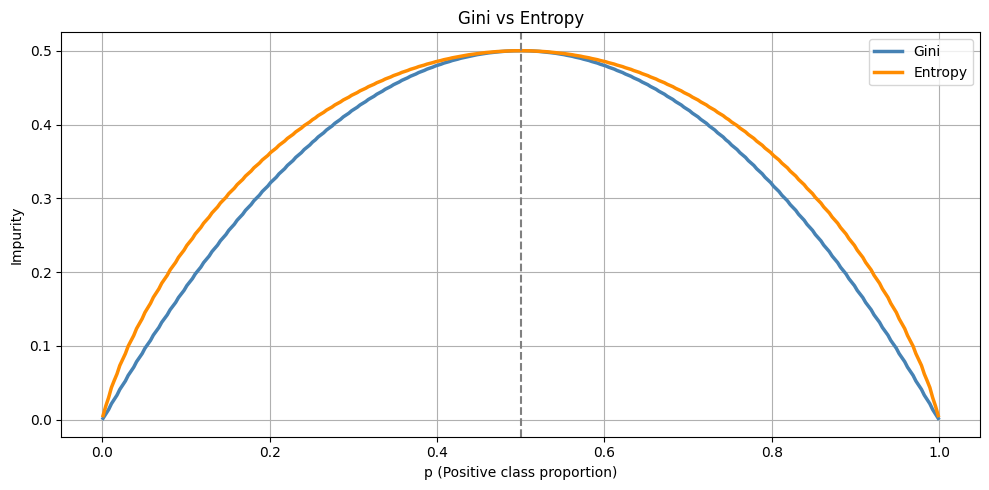

<Figure size 640x480 with 0 Axes>

In [6]:
# p мәндері үшін Gini мен Энтропияны есептеу
p_values = np.linspace(0.001, 0.999, 300)

gini_values = []
entropy_values = []

for p in p_values:
    # p — оң класстың үлесі, (1-p) — теріс класстың үлесі
    # [0, 0, ..., 1, 1, ...] жасайтын жиынды модельдеу орнына
    # функцияларды тікелей ықтималдықтармен шақырамыз
    n = 1000
    y_sample = np.array([0] * int(n * (1 - p)) + [1] * int(n * p))

    gini_values.append(gini_impurity(y_sample))
    entropy_values.append(entropy(y_sample) / 2)  # /2 — нормализация

# TODO: Графикті сызыңыз
# plt.figure() арқылы фигура жасаңыз (figsize=(10, 5))
# Gini үшін: plt.plot(p_values, gini_values, ...) — 'steelblue' түсі, lw=2.5
# Энтропия үшін: plt.plot(p_values, entropy_values, ...) — 'darkorange' түсі, lw=2.5
# plt.axvline(x=0.5, ...) — p=0.5 нүктесін бөлетін тік сызық
# plt.xlabel(), plt.ylabel(), plt.title(), plt.legend(), plt.grid() қосыңыз

# TODO: Осы жерге график кодын жазыңыз
plt.figure(figsize=(10, 5))

plt.plot(p_values, gini_values, color='steelblue', lw=2.5, label='Gini')

plt.plot(p_values, entropy_values, color='darkorange', lw=2.5, label='Entropy')

plt.axvline(x=0.5, color='gray', linestyle='--', lw=1.5)

plt.xlabel('p (Positive class proportion)')
plt.ylabel('Impurity')
plt.title('Gini vs Entropy')

plt.legend()
plt.grid()

# TODO

plt.tight_layout()
plt.show()


## Бөлім 2. Ақпараттық табыс (Information Gain)

**Мақсат:** Бөлу сапасын өлшейтін негізгі метриканы іске асыру.

Ақпараттық табыс — бөлуден бұрынғы және бөлуден кейінгі таза болмаушылық айырмасы. Бұл мән неғұрлым жоғары болса, бөлу соғұрлым тиімді.

### Ақпараттық табыс формуласы

$$IG(S, A) = Gini(S) - \sum_{v} \frac{|S_v|}{|S|} \cdot Gini(S_v)$$

мұнда:
- $S$ — бастапқы жиынтық
- $A$ — бөлу белгісі, $v$ — оның мүмкін мәндері
- $S_v$ — $A = v$ шартын қанағаттандыратын ішкі жиынтық
- $|S_v|/|S|$ — ішкі жиынтықтың салмағы

**Мысал:**

Бастапқы жиын: $y = [0, 0, 1, 1]$, $Gini = 0.5$

Бір белгі бойынша бөлу нәтижесі: сол жақ $y_L = [0, 0]$, оң жақ $y_R = [1, 1]$
- $Gini_L = 0.0$, $Gini_R = 0.0$
- Салмақталған Gini $= \frac{2}{4} \cdot 0 + \frac{2}{4} \cdot 0 = 0$
- $IG = 0.5 - 0 = 0.5$ — өте жақсы бөлу!

In [7]:
def information_gain(y_parent, y_left, y_right):
    y_parent = np.array(y_parent)
    y_left   = np.array(y_left)
    y_right  = np.array(y_right)

    n = len(y_parent)
    n_left = len(y_left)
    n_right= len(y_right)

    parent_gini = gini_impurity(y_parent)

    left_gini  = gini_impurity(y_left)
    right_gini = gini_impurity(y_right)

    weighted_gini = (n_left / n) * left_gini + (n_right / n) * right_gini

    return parent_gini - weighted_gini

In [8]:
# --- ТЕКСЕРУ ---

# Мінсіз бөлу: IG = 0.5 (Gini 0.5-тен 0.0-ге дейін)
y_parent  = [0, 0, 1, 1]
y_left    = [0, 0]
y_right   = [1, 1]
ig = information_gain(y_parent, y_left, y_right)
assert abs(ig - 0.5) < 1e-9, f"Мінсіз бөлу үшін IG 0.5 болуы керек, бірақ {ig} шықты"

# Пайдасыз бөлу: IG = 0 (бөлу ешнәрсені жақсартпайды)
y_parent  = [0, 1, 0, 1]
y_left    = [0, 1]
y_right   = [0, 1]
ig_zero = information_gain(y_parent, y_left, y_right)
assert abs(ig_zero - 0.0) < 1e-9, f"Пайдасыз бөлу үшін IG 0 болуы керек, бірақ {ig_zero} шықты"

print('Барлық тексерулер ОТКЕН.')
print(f'  Мінсіз бөлу IG   = {information_gain([0,0,1,1], [0,0], [1,1]):.4f}  (күтілген: 0.5)')
print(f'  Пайдасыз бөлу IG = {information_gain([0,1,0,1], [0,1], [0,1]):.4f}  (күтілген: 0.0)')

Барлық тексерулер ОТКЕН.
  Мінсіз бөлу IG   = 0.5000  (күтілген: 0.5)
  Пайдасыз бөлу IG = 0.0000  (күтілген: 0.0)



## Бөлім 3. Ең жақсы бөлуді іздеу

**Мақсат:** Берілген деректер жиынтығы үшін ең жоғары IG беретін белгі мен шекара мәнін табу.

Шешім ағашының әр түйінінде осы функция шақырылады.

### Алгоритм

Барлық белгілер мен барлық мүмкін бөлу шекаралары үшін IG есептеп, ең жоғарысын таңдаймыз:

```
best_ig = -1
for feature in барлық белгілер:
    for threshold in feature-тің бірегей мәндері:
        y_left  = y[X[:, feature] <= threshold]
        y_right = y[X[:, feature] >  threshold]
        ig = information_gain(y, y_left, y_right)
        if ig > best_ig:
            best_ig = ig
            best_feature, best_threshold = feature, threshold
```

In [10]:
def find_best_split(X, y):
    """
    Ең жоғары ақпараттық табыс беретін белгі мен шекараны табады.

    Параметрлер:
    -----------
    X : np.ndarray, shape (n_samples, n_features)
        Белгілер матрицасы
    y : np.ndarray, shape (n_samples,)
        Класс белгілері

    Қайтарады:
    ----------
    best_feature  : int   — ең жақсы бөлу белгісінің индексі
    best_threshold: float — ең жақсы бөлу шекарасы
    best_ig       : float — сол бөлудің IG мәні
    """
    X = np.array(X)
    y = np.array(y)

    n_features    = X.shape[1]
    best_ig        = -1
    best_feature   = None
    best_threshold = None

    # TODO: Барлық белгілер бойынша цикл жазыңыз
    for feature_idx in range(n_features):

        # TODO: Осы белгінің бірегей мәндерін алыңыз (бөлу шекаралары)
        # Hint: np.unique(X[:, feature_idx])
        thresholds = np.unique(X[:, feature_idx])

        # TODO: Барлық шекара мәндері бойынша цикл жазыңыз
        for threshold in thresholds:

            # TODO: Деректерді екіге бөліңіз
            # Сол жақ: X[:, feature_idx] <= threshold шартын қанағаттандыратындар
            # Оң жақ: қалғандары
            left_mask = X[:, feature_idx] <= threshold
            right_mask = X[:, feature_idx] > threshold

            y_left  = y[left_mask]
            y_right = y[right_mask]

            # Кем дегенде 1 үлгі болуы керек
            if len(y_left) == 0 or len(y_right) == 0:
                continue

            # TODO: information_gain() функциясын шақырыңыз
            ig = information_gain(y, y_left, y_right)

            # TODO: Егер бұл IG жоғары болса — жаңартыңыз
            if ig > best_ig:
                best_ig = ig
                best_feature = feature_idx
                best_threshold = threshold

    return best_feature, best_threshold, best_ig

In [11]:
# --- ТЕКСЕРУ ---
# Қарапайым деректерде ең жақсы бөлуді табу

X_simple = np.array([
    [1.0],
    [2.0],
    [3.0],
    [4.0],
])
y_simple = np.array([0, 0, 1, 1])

feat, thresh, ig_val = find_best_split(X_simple, y_simple)

assert feat == 0, f"Белгі индексі 0 болуы керек, бірақ {feat} шықты"
assert thresh in [2.0, 3.0], f"Шекара 2.0 немесе 3.0 болуы керек, бірақ {thresh} шықты"
assert abs(ig_val - 0.5) < 1e-9, f"IG 0.5 болуы керек, бірақ {ig_val} шықты"

print('Барлық тексерулер ОТКЕН.')
print(f'  Ең жақсы белгі:    {feat}')
print(f'  Ең жақсы шекара:   {thresh}')
print(f'  Ақпараттық табыс:  {ig_val:.4f}')

Барлық тексерулер ОТКЕН.
  Ең жақсы белгі:    0
  Ең жақсы шекара:   2.0
  Ақпараттық табыс:  0.5000


## Бөлім 4. Шешім ағашы классификаторы

**Мақсат:** Жоғарыда жазған функцияларды бір классқа біріктіріп, толық жұмыс жасайтын шешім ағашын жасау.

Ағаш рекурсивті түрде өседі: әр түйін ең жақсы бөлуді тауып, екі ішкі ағашқа бөлінеді.

In [12]:
# Ағаш түйінін сипаттайтын структура — бұл ұяшықты өзгертпеңіз
class TreeNode:
    """
    Шешім ағашының бір түйіні.

    Ішкі түйін (internal node):
        feature, threshold, left, right өрістері толтырылады.

    Жапырақ түйін (leaf node):
        value өрісі толтырылады — болжанатын класс.
    """
    def __init__(self):
        self.feature   = None   # Бөлу белгісінің индексі
        self.threshold = None   # Бөлу шекарасы
        self.left      = None   # Сол ішкі ағаш (TreeNode)
        self.right     = None   # Оң ішкі ағаш (TreeNode)
        self.value     = None   # Жапырақ болжамы (класс)

    def is_leaf(self):
        return self.value is not None

print('TreeNode класы дайын.')

TreeNode класы дайын.


In [14]:
class MyDecisionTree:
    """
    Шешім ағашы классификаторы.
    """

    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.root              = None

    # ------------------------------------------------------------------
    # ЖАПЫРАҚ ТҮЙІН ЖАСАУ
    # ------------------------------------------------------------------

    def _make_leaf(self, y):
        """
        y жиынтығының ең жиі кездесетін класын жапырақ мәні ретінде қайтарады.
        """
        node = TreeNode()
        node.value = np.bincount(y).argmax()
        return node

    # ------------------------------------------------------------------
    # АҒАШТЫ РЕКУРСИВТІ ӨСІРУ
    # ------------------------------------------------------------------

    def _build(self, X, y, depth):
        """
        Рекурсивті ағаш өсіру функциясы.
        """

        # --- ТОҚТАТУ ШАРТЫ 1: максималды тереңдік ---
        if depth >= self.max_depth:
            return self._make_leaf(y)

        # --- ТОҚТАТУ ШАРТЫ 2: үлгілер саны аз ---
        if len(y) < self.min_samples_split:
            return self._make_leaf(y)

        # --- ТОҚТАТУ ШАРТЫ 3: барлығы бір класс ---
        if len(np.unique(y)) == 1:
            return self._make_leaf(y)

        # --- ЕҢ ЖАҚСЫ БӨЛУДІ ІЗДЕУ ---
        best_feature, best_threshold, best_ig = find_best_split(X, y)

        # Егер пайдалы бөлу табылмаса
        if best_feature is None or best_ig <= 0:
            return self._make_leaf(y)

        # --- ДЕРЕКТЕРДІ БӨЛУ ---
        left_mask  = X[:, best_feature] <= best_threshold
        right_mask = X[:, best_feature] > best_threshold

        # --- ІШКІ АҒАШТАРДЫ РЕКУРСИВТІ ӨСІРУ ---
        node           = TreeNode()
        node.feature   = best_feature
        node.threshold = best_threshold

        node.left  = self._build(X[left_mask], y[left_mask], depth + 1)
        node.right = self._build(X[right_mask], y[right_mask], depth + 1)

        return node

    # ------------------------------------------------------------------
    # FIT — ҮЙРЕТУ
    # ------------------------------------------------------------------

    def fit(self, X, y):
        """
        Ағашты үйрету: _build() рекурсиясын тереңдік 0-ден бастайды.
        """
        self.root = self._build(np.array(X), np.array(y), depth=0)
        return self

    # ------------------------------------------------------------------
    # PREDICT — БОЛЖАМ
    # ------------------------------------------------------------------

    def _traverse(self, x, node):
        """
        Бір үлгіні ағаш бойынша жапыраққа дейін жіберу.
        """
        if node.is_leaf():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse(x, node.left)
        else:
            return self._traverse(x, node.right)

    def predict(self, X):
        """
        Барлық үлгілер үшін болжам жасайды.
        """
        X = np.array(X)
        return np.array([self._traverse(x, self.root) for x in X])

print('MyDecisionTree класы анықталды.')

MyDecisionTree класы анықталды.



## Бөлім 5. Iris деректер жиынтығында үйрету

**Мақсат:** Жазған ағашты нақты деректерде тексеру және scikit-learn нәтижесімен салыстыру.

**Iris деректері:** 150 гүл үлгісі, 4 белгі (тостағанша ұзындығы/ені, күлте ұзындығы/ені), 3 класс (Setosa, Versicolor, Virginica).

In [16]:
# Деректерді жүктеу — бұл ұяшықты өзгертпеңіз
iris = load_iris()
X    = iris.data
y    = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in y]

print('Iris деректер жиынтығы:')
print(f'  Үлгілер саны:  {X.shape[0]}')
print(f'  Белгілер саны: {X.shape[1]}')
print(f'  Класстар:      {list(iris.target_names)}')
print()
print('Класстардың үлестірімі:')
print(df['species'].value_counts().to_string())
print()
df.head()

Iris деректер жиынтығы:
  Үлгілер саны:  150
  Белгілер саны: 4
  Класстар:      [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Класстардың үлестірімі:
species
setosa        50
versicolor    50
virginica     50



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [17]:
# TODO: Деректерді үйрету және тестілеу жиынтықтарына бөліңіз
# Параметрлер: test_size=0.2, random_state=42, stratify=y
# Hint: train_test_split(X, y, test_size=..., random_state=..., stratify=...)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Үйрету жиынтығы:  {X_train.shape[0]} үлгі')
print(f'Тестілеу жиынтығы: {X_test.shape[0]} үлгі')

Үйрету жиынтығы:  120 үлгі
Тестілеу жиынтығы: 30 үлгі


In [18]:
from sklearn.metrics import accuracy_score

# MyDecisionTree моделін құру
my_tree = MyDecisionTree(max_depth=4, min_samples_split=5)

# Үйрету
my_tree.fit(X_train, y_train)

# Болжам
y_pred_my = my_tree.predict(X_test)

# Дәлдік
acc_my = accuracy_score(y_test, y_pred_my)

print(f'Менің ағашымның дәлдігі: {acc_my:.4f} ({acc_my*100:.2f}%)')

Менің ағашымның дәлдігі: 0.9667 (96.67%)


In [19]:
from sklearn.tree import DecisionTreeClassifier

# sklearn моделін құру
sk_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_split=5,
    random_state=42
)

# Үйрету
sk_tree.fit(X_train, y_train)

# Болжам
y_pred_sk = sk_tree.predict(X_test)

# Дәлдік
acc_sk = accuracy_score(y_test, y_pred_sk)

print(f'scikit-learn ағашының дәлдігі: {acc_sk:.4f} ({acc_sk*100:.2f}%)')
print()
print('--- Салыстыру ---')
print(f'Менің ағашым:  {acc_my*100:.2f}%')
print(f'scikit-learn:  {acc_sk*100:.2f}%')

scikit-learn ағашының дәлдігі: 0.9667 (96.67%)

--- Салыстыру ---
Менің ағашым:  96.67%
scikit-learn:  96.67%



## Бөлім 6. Нәтижелерді талдау

**Мақсат:** Шатасу матрицасын сызу, белгілердің маңыздылығын визуализациялау, scikit-learn ағашын визуализациялау.

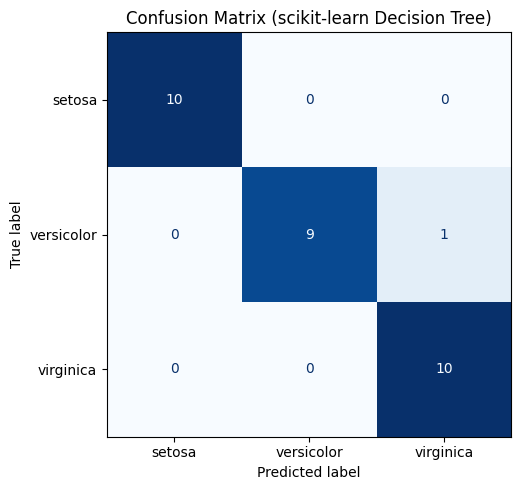

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# class атауларын алу үшін
iris = load_iris()

# Confusion matrix есептеу
cm = confusion_matrix(y_test, y_pred_sk)

# Визуализация
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Confusion Matrix (scikit-learn Decision Tree)')

plt.tight_layout()
plt.show()

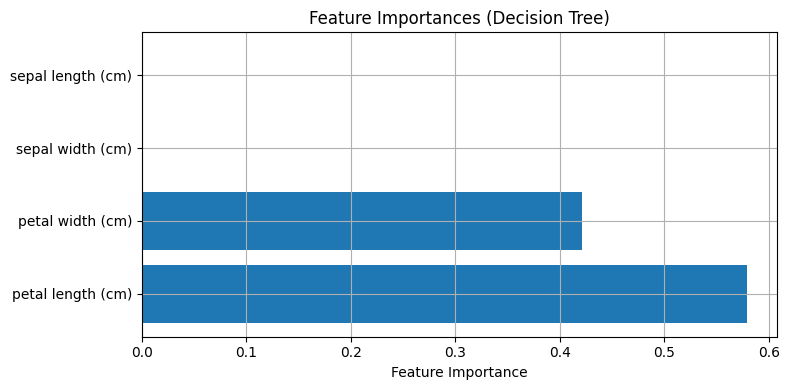

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()

# Маңыздылықтарды алу
importances = sk_tree.feature_importances_

# Кему ретімен сорттау
sorted_idx = np.argsort(importances)[::-1]

# Белгі атаулары
feature_names = iris.feature_names

# График
plt.figure(figsize=(8, 4))

plt.barh(
    range(len(sorted_idx)),
    importances[sorted_idx],
    align='center'
)

plt.yticks(range(len(sorted_idx)), np.array(feature_names)[sorted_idx])

plt.xlabel('Feature Importance')
plt.title('Feature Importances (Decision Tree)')
plt.grid()

plt.tight_layout()
plt.show()

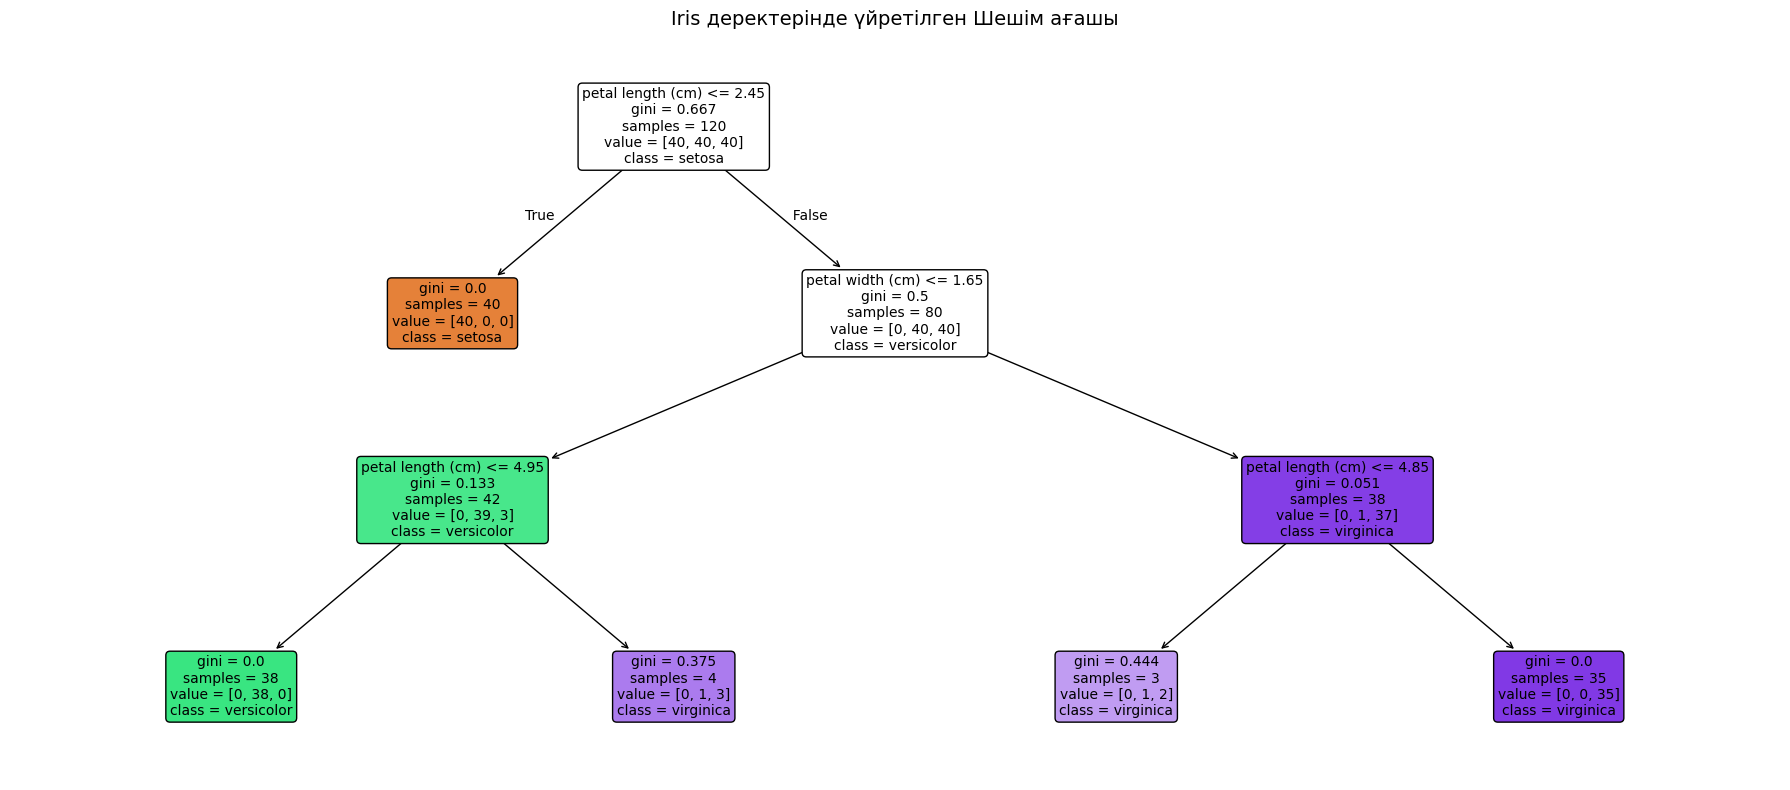

In [23]:
from sklearn.tree import plot_tree
from sklearn.datasets import load_iris

iris = load_iris()

plt.figure(figsize=(18, 8))

plot_tree(
    sk_tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)

plt.title('Iris деректерінде үйретілген Шешім ағашы', fontsize=14)
plt.tight_layout()
plt.show()


## Бөлім 7. Оңтайлы тереңдікті табу

**Мақсат:** Ағаштың тереңдігі өскен сайын үйрету дәлдігі артады, бірақ тест дәлдігі белгілі бір нүктеден кейін төмендей бастайды — бұл **асыра оқыту** белгісі.

Осы нүктені анықтау үшін тереңдіктердің ауқымы бойынша эксперимент жүргіземіз.

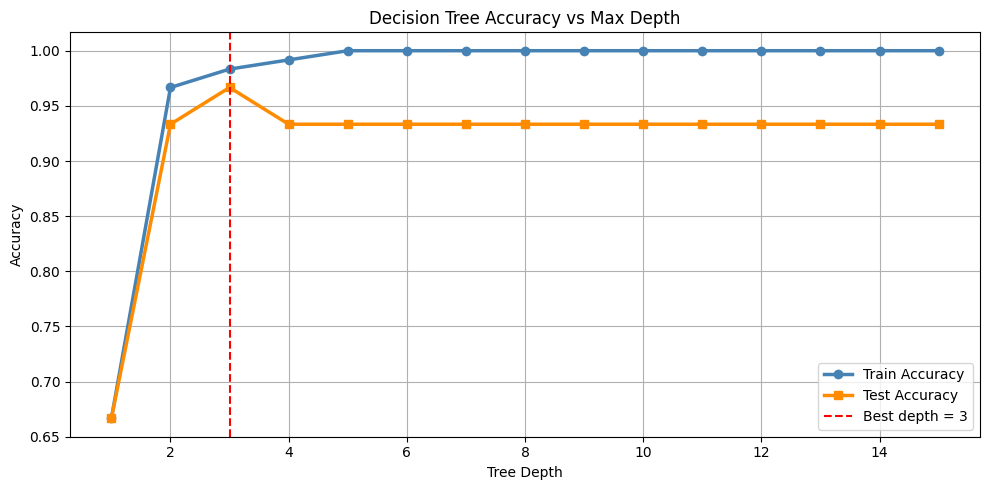

Оңтайлы тереңдік: 3
Тест дәлдігі:     0.9667


In [24]:
# TODO: max_depth = 1-ден 15-ке дейін әр мән үшін:
#   1. DecisionTreeClassifier үйретіңіз (criterion='gini', random_state=42)
#   2. Үйрету дәлдігін (X_train, y_train бойынша) тізімге қосыңыз
#   3. Тест дәлдігін (X_test, y_test бойынша) тізімге қосыңыз

depths       = range(1, 16)
train_scores = []
test_scores  = []

for depth in depths:
    # Үлгіні жасау және үйрету
    dt = DecisionTreeClassifier(
        criterion='gini',
        max_depth=depth,
        random_state=42
    )
    dt.fit(X_train, y_train)

    # Дәлдіктерді сақтау
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores.append(accuracy_score(y_test, dt.predict(X_test)))

# Ең жақсы тереңдік
best_depth = depths[np.argmax(test_scores)]

# График
plt.figure(figsize=(10, 5))

plt.plot(depths, train_scores, 'o-', color='steelblue', lw=2.5, label='Train Accuracy')
plt.plot(depths, test_scores, 's-', color='darkorange', lw=2.5, label='Test Accuracy')

plt.axvline(x=best_depth, color='red', linestyle='--', lw=1.5, label=f'Best depth = {best_depth}')

plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs Max Depth')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

print(f'Оңтайлы тереңдік: {best_depth}')
print(f'Тест дәлдігі:     {test_scores[best_depth - 1]:.4f}')


## Бөлім 8. Қорытынды сұрақтар

**Мақсат:** Меңгерілген материалды ой жүгіртіп бекіту.

Әр сұраққа Markdown ұяшығында жауап жазыңыз. Жауаптарыңызды `# TODO` орнына жазыңыз.

### Сұрақ 1

Gini таза болмау индексі мен Энтропияның негізгі айырмашылығы неде? Қай жағдайда қайсысын таңдаған дұрыс?


Gini және Энтропия — екеуі де деректердің “таза болмауын” өлшейді.

Gini:қарапайым және тез есептеледі (квадраттар)
Entropy: ақпараттық теорияға негізделген (log₂)

Айырмашылығы:

Entropy өзгерістерге сезімтал
Gini жылдамырақ

Қай кезде қайсысы:

Үлкен деректерде->Gini (жылдам)

### Сұрақ 2

max_depth параметрін өте үлкен мән (мысалы, 100) ретінде қойсақ не болады? Бөлім 7-дегі графикке сүйеніп түсіндіріңіз.



гер max_depth өте үлкен (мысалы 100) болса:

Модель overfitting жасайды
Train accuracy ≈ 100% болады
Test accuracy төмендейді

График бойынша:

Бір жерге дейін өседі
Сосын төмен түседі

### Сұрақ 3

Шешім ағашы масштабтауды (StandardScaler) неге қажет етпейді? kNN алгоритмімен салыстырыңыз.



Decision Tree масштабтауды қажет етпейді, себебі:

Ол тек шектермен (threshold) жұмыс істейді
Мәндердің абсолютті өлшемі маңызды емес

Ал kNN:

Қашықтыққа негізделген
Сондықтан масштабтау міндетті

### Сұрақ 4

Белгілердің маңыздылығы диаграммасына қарап: Iris деректерінде гүл түрін анықтау үшін ең маңызды белгі қайсысы? Бұл биологиялық тұрғыдан мағынасы бар ма?


Iris деректерінде ең маңызды белгілер:

petal length
petal width

Бұл биологиялық тұрғыдан мағыналы, себебі:

Гүл түрлері көбіне күлтелерінің өлшемімен ажыратылады
Setosa басқа түрлерден анық ерекшеленеді. Сондықтан модель дұрыс биологиялық белгілерді таңдаған.


## Қосымша тапсырма (міндетті емес)

**Мақсат:** Тереңірек зерттегісі келетіндерге арналған кеңейтілген тапсырма.

MyDecisionTree классына **Энтропия** критерийін қосыңыз:

1. `__init__`-ке `criterion='gini'` параметрін қосыңыз
2. `find_best_split`-тен тәуелсіз `_information_gain(y, y_left, y_right)` әдісін класс ішіне қосыңыз
3. Ішінде таңдалған критерийге қарай `gini_impurity` немесе `entropy` функциясын шақырыңыз
4. Iris деректерінде екі нұсқаны (`criterion='gini'` және `criterion='entropy'`) салыстырыңыз

In [ ]:
# TODO (қосымша): MyDecisionTree-ні энтропия критерийімен кеңейтіңіз
# Осы жерге кодыңызды жазыңыз
